# Pipeline 

#### 1. Setup & Import

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.calibration import intercept_recalibration, FlexibleCalibratedModel
from src.decisioning import my_impact, my_thresholds, my_thresholds_li
from src.feature_engineering import create_target_def12, FeatureSelector, SpecialMappings
from src.metrics import my_metrics
from src.plots import default_capture_curve, my_calibration, variable_vs_dr
from src.preprocessing import my_input_load, my_time_split, ReplaceMinusOne 
from src.validation import missing_summary

# ML modules

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import statsmodels.api as sm
import xgboost

# Configuration

from sklearn import set_config; set_config(transform_output="pandas") # set sklearn output: pandas


#### 2. Data Loading

In [3]:
# load input file

full_dataset = my_input_load(2016, 2020)

#### 3. Target Definition

In [4]:
# CREATE TARGET VARIABLE

full_dataset, dr_summary = create_target_def12(full_dataset)

LoanDate range:     2016-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2017-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2016-04-29 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2016,6023,1282,0.212851
2017,11109,2447,0.220272
2018,16946,2865,0.169066
2019,28487,4879,0.171271
2020,19959,2294,0.114936


#### 4. Split

In [5]:
# TRAIN/TEST SPLIT

X_trai, y_trai, X_test, y_test = my_time_split(full_dataset, 2016, 2018, 2019, 2020)

Train size: (34078, 105) (34078,)
Test size : (48446, 105) (48446,)
LoanYear
2018    16946
2017    11109
2016     6023
Name: count, dtype: int64
LoanYear
2019    28487
2020    19959
Name: count, dtype: int64
Train default rate: 0.19349727096660602
Test default rate : 0.1480617594847872


#### 5. Feature Groups

In [6]:
# DEFINE NOMINAL-CATEGORICAL VARIABLES FOR FINAL MODEL (before pre-processing)

num_cols = [
                 "CreditScoreEeMini",
                               "Age",
      "PreviousRepaymentsBeforeLoan",
                     "AppliedAmount",
   "AmountOfPreviousLoansBeforeLoan",
                    "MonthlyPayment",
             "ApplicationSignedHour",
               "ExistingLiabilities",
                      "LoanDuration",
                  "LiabilitiesTotal",
 "EmploymentDurationCurrentEmployer",
                            "Amount",
       "IncomeFromPrincipalEmployer",
                          "FreeCash",
                    "WorkExperience"
]

cat_cols = [
                "NewCreditCustomer",
                "HomeOwnershipType",
                     "LanguageCode",
                 "VerificationType",
                        "Education"
]

# DEFINE VARIABLES FOR FINAL MODEL (after pre-processing)

selected_features = [
                 "num__CreditScoreEeMini",
                               "num__Age",
      "num__PreviousRepaymentsBeforeLoan",
                     "num__AppliedAmount",
   "num__AmountOfPreviousLoansBeforeLoan",
                    "num__MonthlyPayment",
             "num__ApplicationSignedHour",
               "num__ExistingLiabilities",
                      "num__LoanDuration",
                  "num__LiabilitiesTotal",
 "num__EmploymentDurationCurrentEmployer",
                            "num__Amount",
       "num__IncomeFromPrincipalEmployer",
                          "num__FreeCash",
                    "num__WorkExperience",
             "cat__NewCreditCustomer_1.0",
             "cat__HomeOwnershipType_8.0",
                  "cat__LanguageCode_3.0",
              "cat__VerificationType_4.0",
                     "cat__Education_5.0",
                     "cat__Education_2.0",
             "cat__HomeOwnershipType_3.0"
                    # ... all 22
]


#### 6. Pre-processing Pipelines

In [7]:
# assemble pre-processing pipeline

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=False))    
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

#### 7. Full Pipeline

In [8]:
# assemble the end-to-end modelling pipeline

pipeline = Pipeline([
    ("replace_minus_one", ReplaceMinusOne(verbose=True)),
    ("special_mappings", SpecialMappings()),
    ("preprocessing", preprocessor),
    ("scaler", StandardScaler()),
    ("feature_selection", FeatureSelector(selected_features)),
    #("model", LogisticRegression(max_iter=10000, random_state=888))
    ("model", FlexibleCalibratedModel(
        base_model=LogisticRegression(max_iter=10000, random_state=888),
        calibration="shift", # "shift", "sigmoid", "isotonic", None
        shift=-0.38330530029264454
    ))
])

#### 8. Training

In [9]:
# training

pipeline.fit(X_trai, y_trai)

Education: replacing 2 values of -1 with NaN
EmploymentStatus: replacing 24,269 values of -1 with NaN
HomeOwnershipType: replacing 2 values of -1 with NaN
MaritalStatus: replacing 24,269 values of -1 with NaN
OccupationArea: replacing 24,269 values of -1 with NaN
UseOfLoan: replacing 24,269 values of -1 with NaN


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('replace_minus_one', ...), ('special_mappings', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

#### 9. Prediction & Evaluation

##### Validation (old model replication)

In [10]:
# TEST 1: pipeline features

pipe_features = pipeline.named_steps["feature_selection"].selected_features
print(len(pipe_features))
print(pipe_features)

22
['num__CreditScoreEeMini', 'num__Age', 'num__PreviousRepaymentsBeforeLoan', 'num__AppliedAmount', 'num__AmountOfPreviousLoansBeforeLoan', 'num__MonthlyPayment', 'num__ApplicationSignedHour', 'num__ExistingLiabilities', 'num__LoanDuration', 'num__LiabilitiesTotal', 'num__EmploymentDurationCurrentEmployer', 'num__Amount', 'num__IncomeFromPrincipalEmployer', 'num__FreeCash', 'num__WorkExperience', 'cat__NewCreditCustomer_1.0', 'cat__HomeOwnershipType_8.0', 'cat__LanguageCode_3.0', 'cat__VerificationType_4.0', 'cat__Education_5.0', 'cat__Education_2.0', 'cat__HomeOwnershipType_3.0']


In [11]:
# TEST 2: pipeline output shape without model
# (new pipe is defined)

pipe_no_model = Pipeline([
    ("replace_minus_one", ReplaceMinusOne()),
    ("special_mappings", SpecialMappings()),
    ("preprocessing", preprocessor),
    ("scaler", StandardScaler()),
    ("feature_selection", FeatureSelector(selected_features))
])

X_trai_pipe = pipe_no_model.fit_transform(X_trai, y_trai)
print(X_trai_pipe.shape)

(34078, 22)


In [12]:
# TEST 3: column names

print(X_trai_pipe.info())

# comparison with old training set (X_trai_pipe = X_trai_old)

X_trai_old = pd.read_pickle("../archive/old_predictions/X_train_old.pkl")
#print(X_trai_old.info())
# rename
rename_map = {
    "Age": "num__Age",
    "Amount": "num__Amount",
    "CreditScoreEeMini": "num__CreditScoreEeMini",
    "PreviousRepaymentsBeforeLoan": "num__PreviousRepaymentsBeforeLoan",
    "AppliedAmount": "num__AppliedAmount",
    "AmountOfPreviousLoansBeforeLoan": "num__AmountOfPreviousLoansBeforeLoan",
    "MonthlyPayment": "num__MonthlyPayment",
    "ApplicationSignedHour": "num__ApplicationSignedHour",
    "ExistingLiabilities": "num__ExistingLiabilities",
    "LoanDuration": "num__LoanDuration",
    "LiabilitiesTotal": "num__LiabilitiesTotal",
    "EmploymentDurationCurrentEmployer": "num__EmploymentDurationCurrentEmployer",
    "IncomeFromPrincipalEmployer": "num__IncomeFromPrincipalEmployer",
    "FreeCash": "num__FreeCash",
    "WorkExperience": "num__WorkExperience",
    "NewCreditCustomer": "cat__NewCreditCustomer_1.0",
    "HomeOwnershipType_8.0": "cat__HomeOwnershipType_8.0", 
    "LanguageCode_3": "cat__LanguageCode_3.0",
    "VerificationType_4.0": "cat__VerificationType_4.0",
    "Education_5.0": "cat__Education_5.0",
    "Education_2.0": "cat__Education_2.0",
    "HomeOwnershipType_3.0": "cat__HomeOwnershipType_3.0"  
    # ... complete for all 22
}
X_trai_old_renamed = X_trai_old.rename(columns=rename_map)
#print(X_trai_old_renamed.info())
# reorder
X_trai_old_aligned = X_trai_old_renamed[X_trai_pipe.columns]
print(X_trai_old_aligned.info())

<class 'pandas.DataFrame'>
Index: 34078 entries, 0 to 82523
Data columns (total 22 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   num__CreditScoreEeMini                  34078 non-null  float64
 1   num__Age                                34078 non-null  float64
 2   num__PreviousRepaymentsBeforeLoan       34078 non-null  float64
 3   num__AppliedAmount                      34078 non-null  float64
 4   num__AmountOfPreviousLoansBeforeLoan    34078 non-null  float64
 5   num__MonthlyPayment                     34078 non-null  float64
 6   num__ApplicationSignedHour              34078 non-null  float64
 7   num__ExistingLiabilities                34078 non-null  float64
 8   num__LoanDuration                       34078 non-null  float64
 9   num__LiabilitiesTotal                   34078 non-null  float64
 10  num__EmploymentDurationCurrentEmployer  34078 non-null  float64
 11  num__

In [13]:
# TEST 4: values

# reset index
X_trai_old_aligned = X_trai_old_aligned.reset_index(drop=True)
X_trai_pipe_aligned = X_trai_pipe.reset_index(drop=True)
# compare values
(X_trai_pipe_aligned.round(6) == X_trai_old_aligned.round(6)).all().all()

np.True_

In [14]:
# TEST 5: feature distribution

print(X_trai_pipe_aligned.describe().T[["mean","std"]])
print(X_trai_old_aligned.describe().T[["mean","std"]])

                                                mean       std
num__CreditScoreEeMini                 -3.336077e-16  1.000015
num__Age                                6.004939e-17  1.000015
num__PreviousRepaymentsBeforeLoan       2.668862e-17  1.000015
num__AppliedAmount                      6.672154e-17  1.000015
num__AmountOfPreviousLoansBeforeLoan    1.334431e-17  1.000015
num__MonthlyPayment                     1.067545e-16  1.000015
num__ApplicationSignedHour             -4.670508e-17  1.000015
num__ExistingLiabilities                1.334431e-17  1.000015
num__LoanDuration                       0.000000e+00  1.000015
num__LiabilitiesTotal                   2.668862e-17  1.000015
num__EmploymentDurationCurrentEmployer -1.734760e-16  1.000015
num__Amount                             6.004939e-17  1.000015
num__IncomeFromPrincipalEmployer        5.337723e-17  1.000015
num__FreeCash                           1.334431e-17  1.000015
num__WorkExperience                     1.200988e-16  1

In [15]:
# TEST 6: single feature 

col = "cat__Education_2.0"

pd.concat([
    X_trai_pipe_aligned[col],
    X_trai_old_aligned[col]
], axis=1).head(10)

,cat__Education_2.0,cat__Education_2.0
0,-0.274818,-0.274818
1,-0.274818,-0.274818
2,3.638778,3.638778
3,-0.274818,-0.274818
4,3.638778,3.638778
5,-0.274818,-0.274818
6,-0.274818,-0.274818
7,-0.274818,-0.274818
8,-0.274818,-0.274818
9,-0.274818,-0.274818


In [17]:
# TEST 7: model coefficients

# feature names
pipe_feature_names = pipeline.named_steps["feature_selection"].selected_features
print(pipe_feature_names)

# coefficients
coeffs = pipeline.named_steps["model"].coef_[0]
print(coeffs)

# coefficients sorted
coef_df = pd.DataFrame({
    "feature": pipe_feature_names,
    "coefficient": coeffs,
    "abs_coefficient": abs(coeffs)
}).sort_values("abs_coefficient", ascending=False)
print(coef_df)

['num__CreditScoreEeMini', 'num__Age', 'num__PreviousRepaymentsBeforeLoan', 'num__AppliedAmount', 'num__AmountOfPreviousLoansBeforeLoan', 'num__MonthlyPayment', 'num__ApplicationSignedHour', 'num__ExistingLiabilities', 'num__LoanDuration', 'num__LiabilitiesTotal', 'num__EmploymentDurationCurrentEmployer', 'num__Amount', 'num__IncomeFromPrincipalEmployer', 'num__FreeCash', 'num__WorkExperience', 'cat__NewCreditCustomer_1.0', 'cat__HomeOwnershipType_8.0', 'cat__LanguageCode_3.0', 'cat__VerificationType_4.0', 'cat__Education_5.0', 'cat__Education_2.0', 'cat__HomeOwnershipType_3.0']
[-0.2360244  -0.15493341 -0.1386618   0.13610417  0.11856865  0.11827231
 -0.11246062  0.10186358  0.07772976 -0.070984   -0.06993566 -0.06221312
 -0.03899022  0.03491318 -0.02884038  0.23976611 -0.17653744  0.12487754
 -0.11443437 -0.10086082  0.06327427  0.05256039]
                                   feature  coefficient  abs_coefficient
15              cat__NewCreditCustomer_1.0     0.239766         0.239766

##### Prediction

Education: replacing 2 values of -1 with NaN
EmploymentStatus: replacing 24,269 values of -1 with NaN
HomeOwnershipType: replacing 2 values of -1 with NaN
MaritalStatus: replacing 24,269 values of -1 with NaN
OccupationArea: replacing 24,269 values of -1 with NaN
UseOfLoan: replacing 24,269 values of -1 with NaN
EmploymentStatus: replacing 48,446 values of -1 with NaN
MaritalStatus: replacing 48,446 values of -1 with NaN
OccupationArea: replacing 48,446 values of -1 with NaN
UseOfLoan: replacing 48,446 values of -1 with NaN


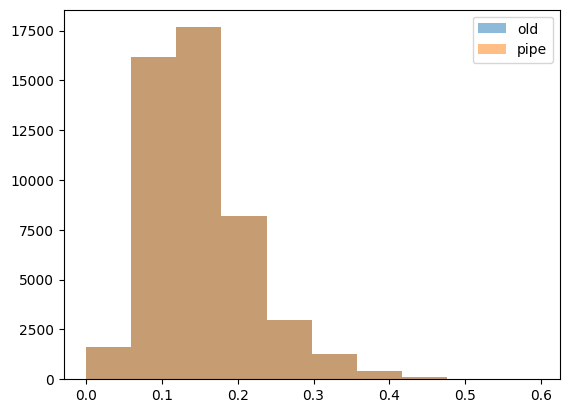

In [18]:
# prediction
y_pred_trai_pipe = pipeline.predict_proba(X_trai)[:,1]
y_pred_test_pipe = pipeline.predict_proba(X_test)[:,1]

# load old model PDs
y_pred_test_old = pd.read_pickle("../archive/old_predictions/y_pred_test_old.pkl")

# compare pipe PDs / old PDs
plt.hist(y_pred_test_old , alpha=0.5, label="old")
plt.hist(y_pred_test_pipe, alpha=0.5, label="pipe")
plt.legend()
plt.show()


#### 10. Export Pipeline

In [ ]:
# export trained pipeline

import joblib
joblib.dump(pipeline, "PIPELINE_ver_01_cal_xxxxx-xxxx.pkl")

# pipeline names:

# PIPELINE_ver_01.pkl                -> model version 1.0 calibration shift test
# PIPELINE_ver_01_cal_shift-test.pkl -> model version 1.0 calibration shift test
# PIPELINE_ver_01_cal_none.pkl       -> model version 1.0 calibration none

['PIPELINE_ver_01_cal_shift-test-fixReplaceMinusOne.pkl']